# 04 — Final Neuromorphic Student: Architecture, Distillation & Training

**Purpose:** Train the single deployable model used by the exhibition — the **Improved Student** — from scratch inside this notebook, with **per-epoch logging** for every training run.

## Final architecture

`10 × 30 s PSG epochs → Lite Multi-Resolution Stem → Depthwise-Separable CNN → Parametric Gabor FEB → 2-Layer GRU → 5-Class classifier`

Training is a two-stage process, fully executed in this notebook:

1. **Stage 1 — Improved Teacher:** trained from scratch with focal loss + class weights, per-epoch validation logging.
2. **Stage 2 — Improved Student:** distilled from the teacher (hard-label CE + softened KL + feature alignment), per-epoch validation logging.

Knowledge distillation transfers information from a trained teacher into the smaller student. The teacher is a training-time component only; the student checkpoint is the only model exported for deployment and exhibition.

### Final configuration
- Sequence length: **10 epochs** (300 s context)
- Input channels: **4** | Classes: **5**
- Training budget: **20 epochs per stage**
- Checkpoints: `artifacts/teacher_improved_best.pt`, `artifacts/final/student_full_finetuned.pt`

In [1]:
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from sklearn.metrics import cohen_kappa_score, accuracy_score, f1_score

SEED = 42
SEQ_LEN = 10
SEQ_STRIDE = 5
EPOCHS = 20
BATCH_SIZE = 16
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
N_CHANNELS = 4
N_CLASSES = 5
FS = 100

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT = Path("/home/shamique/projects/sleep")
CACHE_DIR = PROJECT_ROOT / "data/cache"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
RESULTS_DIR = PROJECT_ROOT / "results"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TEACHER_CHECKPOINT = ARTIFACT_DIR / "teacher_improved_best.pt"
STUDENT_CHECKPOINT = ARTIFACT_DIR / "final" / "student_full_finetuned.pt"
STUDENT_CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Teacher checkpoint:", TEACHER_CHECKPOINT)
print("Student checkpoint:", STUDENT_CHECKPOINT)

Device: cuda
Teacher checkpoint: /home/shamique/projects/sleep/artifacts/teacher_improved_best.pt
Student checkpoint: /home/shamique/projects/sleep/artifacts/final/student_full_finetuned.pt


## 1. Sequence dataset

Each training example contains ten contiguous 30-second epochs. Windows are formed independently inside each subject-night cache so no temporal sequence crosses recording boundaries, and the subject-level split from Notebook 01 is respected (no subject leakage).

In [2]:
class SleepSequenceDataset(Dataset):
    def __init__(self, cache_index_df, split, seq_len=SEQ_LEN, stride=SEQ_STRIDE):
        self.samples = []
        self.cache = {}
        self.seq_len = seq_len

        rows = cache_index_df.loc[cache_index_df["split"] == split]

        for _, row in rows.iterrows():
            path = row["cache_path"]
            data = np.load(path)
            n = len(data["labels"])

            for start in range(0, max(n - seq_len + 1, 1), stride):
                self.samples.append((path, start))

    def _load(self, path):
        if path not in self.cache:
            d = np.load(path)
            self.cache[path] = (d["epochs"], d["labels"])
        return self.cache[path]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, start = self.samples[index]
        epochs, labels = self._load(path)

        end = min(start + self.seq_len, len(labels))
        x = epochs[start:end]
        y = labels[start:end]

        if len(x) < self.seq_len:
            pad = self.seq_len - len(x)
            x = np.concatenate([x, np.repeat(x[-1:], pad, axis=0)], axis=0)
            y = np.concatenate([y, np.repeat(y[-1:], pad, axis=0)], axis=0)

        return torch.from_numpy(x).float(), torch.from_numpy(y).long()


cache_index = pd.read_csv(CACHE_DIR / "cache_index.csv")

train_ds = SleepSequenceDataset(cache_index, "train")
val_ds = SleepSequenceDataset(cache_index, "val")
test_ds = SleepSequenceDataset(cache_index, "test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Sequence windows:")
print("train:", len(train_ds))
print("val:  ", len(val_ds))
print("test: ", len(test_ds))

Sequence windows:
train: 31667
val:   7154
test:  7486


## 2. Model architectures

The architecture implementations mirror the project's canonical pipeline (`neuromorphic_sleep_pipeline.py`) so the existing final student checkpoint remains loadable.

**Improved Teacher:** multi-resolution stem → residual encoder → learned spectral filterbank → gated fusion → 2-layer transformer encoder.
**Improved Student (final deployable model):** Lite multi-resolution stem → depthwise-separable CNN → parametric Gabor FEB → 2-layer GRU.

In [3]:
class SEBlock1D(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(ch, max(ch // r, 1)), nn.ReLU(),
            nn.Linear(max(ch // r, 1), ch), nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.fc(x.mean(-1)).unsqueeze(-1)


class ResBlock1D(nn.Module):
    def __init__(self, ch, k=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(ch, ch, k, padding=k // 2, bias=False), nn.BatchNorm1d(ch), nn.GELU(),
            nn.Conv1d(ch, ch, k, padding=k // 2, bias=False), nn.BatchNorm1d(ch),
        )
        self.se = SEBlock1D(ch)
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(self.se(self.net(x)) + x)


class ImprovedTeacher(nn.Module):
    def __init__(self, in_ch=4, n_cls=5, fs=100):
        super().__init__()
        self.stem_short = nn.Sequential(
            nn.Conv1d(in_ch, 16, fs // 4, stride=fs // 8, padding=fs // 8, bias=False),
            nn.BatchNorm1d(16), nn.GELU(),
        )
        self.stem_long = nn.Sequential(
            nn.Conv1d(in_ch, 16, fs * 2, stride=fs // 2, padding=fs, bias=False),
            nn.BatchNorm1d(16), nn.GELU(),
        )
        self.encoder = nn.Sequential(
            ResBlock1D(32), ResBlock1D(32), nn.AdaptiveAvgPool1d(32)
        )
        self.fb_filters = nn.Parameter(torch.randn(32, 129))
        self.fb_proj = nn.Linear(32, 64)
        self.gate_w = nn.Linear(32 + 64, 96)
        enc_layer = nn.TransformerEncoderLayer(96, 4, 192, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, 2)
        self.head = nn.Linear(96, n_cls)
        self.feature_dim = 96

    def forward(self, x, return_features=False):
        B, T, C, S = x.shape
        xf = x.reshape(B * T, C, S)
        ts = self.stem_short(xf)
        tl = self.stem_long(xf)
        L = min(ts.shape[-1], tl.shape[-1])
        t_feat = self.encoder(torch.cat([ts[..., :L], tl[..., :L]], 1)).reshape(B * T, 32, 32).mean(-1)
        spec = torch.fft.rfft(xf[:, 0, :], dim=-1).abs()[:, :129]
        fb = F.softmax(self.fb_filters, -1)
        f_feat = self.fb_proj((spec.unsqueeze(1) * fb.unsqueeze(0)).sum(-1))
        gate = torch.sigmoid(self.gate_w(torch.cat([t_feat, f_feat], -1)))
        fused = torch.cat([t_feat, f_feat], -1) * gate
        seq = fused.reshape(B, T, 96)
        out = self.transformer(seq)
        logits = self.head(out)
        if return_features:
            return logits, fused.reshape(B, T, 96)
        return logits


class DWSep(nn.Module):
    def __init__(self, in_ch, out_ch, k, stride=1):
        super().__init__()
        self.dw = nn.Conv1d(in_ch, in_ch, k, stride=stride, padding=k // 2, groups=in_ch, bias=False)
        self.pw = nn.Conv1d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)
    def forward(self, x):
        return F.gelu(self.bn(self.pw(self.dw(x))))


class ImprovedStudent(nn.Module):
    def __init__(self, in_ch=4, n_cls=5, fs=100):
        super().__init__()
        self.stem_s = nn.Sequential(
            nn.Conv1d(in_ch, 8, fs // 4, stride=fs // 8, padding=fs // 8, bias=False),
            nn.BatchNorm1d(8), nn.GELU(),
        )
        self.stem_l = nn.Sequential(
            nn.Conv1d(in_ch, 8, fs * 2, stride=fs // 2, padding=fs, bias=False),
            nn.BatchNorm1d(8), nn.GELU(),
        )
        self.enc = nn.Sequential(DWSep(16, 32, 5, 2), DWSep(32, 32, 5, 2), nn.AdaptiveAvgPool1d(8))
        self.gabor_freq = nn.Parameter(torch.linspace(1, 30, 8))
        self.gabor_sigma = nn.Parameter(torch.ones(8) * 0.15)
        self.gab_proj = nn.Linear(8, 16)
        self.gru = nn.GRU(32 * 8 + 16, 64, num_layers=2, batch_first=True)
        self.head = nn.Linear(64, n_cls)
        self.feature_dim = 32 * 8 + 16

    def _gabor_feat(self, x):
        k = 51
        t = torch.linspace(-k // 2, k // 2, k, device=x.device)
        filt = []
        for i in range(8):
            g = torch.exp(-t ** 2 / (2 * self.gabor_sigma[i] ** 2 + 1e-6)) * torch.cos(2 * math.pi * self.gabor_freq[i] * t / 100)
            filt.append((x[:, 0, :] * F.conv1d(x[:, 0:1, :], g.view(1, 1, -1), padding=k // 2)[:, 0, :]).mean(-1))
        return self.gab_proj(torch.stack(filt, -1))

    def forward(self, x, return_features=False):
        B, T, C, S = x.shape
        xf = x.reshape(B * T, C, S)
        L = min(self.stem_s(xf).shape[-1], self.stem_l(xf).shape[-1])
        cat = torch.cat([self.stem_s(xf)[..., :L], self.stem_l(xf)[..., :L]], 1)
        enc_feat = self.enc(cat).reshape(B * T, -1)
        gab_feat = self._gabor_feat(xf)
        feat = torch.cat([enc_feat, gab_feat], -1).reshape(B, T, -1)
        out, _ = self.gru(feat)
        logits = self.head(out)
        if return_features:
            return logits, feat
        return logits


teacher = ImprovedTeacher().to(DEVICE)
student = ImprovedStudent().to(DEVICE)

n_teacher = sum(p.numel() for p in teacher.parameters())
n_student = sum(p.numel() for p in student.parameters())
print(f"Improved Teacher parameters: {n_teacher:,}")
print(f"Improved Student parameters: {n_student:,}  (final deployable model)")

with torch.no_grad():
    smoke = torch.randn(2, SEQ_LEN, N_CHANNELS, 30 * FS, device=DEVICE)
    t_logits = teacher(smoke)
    s_logits, s_feat = student(smoke, return_features=True)
print("Teacher logits:", tuple(t_logits.shape))
print("Student logits:", tuple(s_logits.shape), "| features:", tuple(s_feat.shape))

Improved Teacher parameters: 193,197
Improved Student parameters: 99,477  (final deployable model)


Teacher logits: (2, 10, 5)
Student logits: (2, 10, 5) | features: (2, 10, 272)


## 3. Class weighting from the training partition

Class weights are computed from training labels only. The validation and test partitions are never used to determine training weights.

In [4]:
train_labels = []

for _, row in cache_index.loc[cache_index["split"] == "train"].iterrows():
    train_labels.append(np.load(row["cache_path"])["labels"])

train_labels = np.concatenate(train_labels)
class_counts = np.bincount(train_labels, minlength=N_CLASSES)

counts = torch.tensor(class_counts, dtype=torch.float32, device=DEVICE)
class_weights = torch.log(counts.sum() / (counts + 1.0))
class_weights = class_weights / class_weights.mean()

print("Training class counts:", class_counts.tolist())
print("Class weights:", [round(float(w), 3) for w in class_weights])

Training class counts: [110364, 7787, 25268, 5525, 9866]
Class weights: [0.16, 1.328, 0.809, 1.479, 1.224]


## 4. Training objectives

**Teacher — Focal loss** (imbalance-aware supervision):

**Student — Distillation loss:** hard-label cross-entropy + temperature-scaled teacher-student KL divergence, exactly as in the canonical pipeline.

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, weight, gamma=1.5):
        super().__init__()
        self.w = weight
        self.gamma = gamma

    def forward(self, logits, labels):
        C = logits.shape[-1]
        ce = F.cross_entropy(
            logits.reshape(-1, C), labels.reshape(-1),
            weight=self.w.to(logits.device), reduction="none",
        )
        return (((1 - torch.exp(-ce)) ** self.gamma) * ce).mean()


class DistillLoss(nn.Module):
    def __init__(self, weight, T_s=8, T_e=4, epochs=EPOCHS):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight)
        self.Ts, self.Te, self.epochs = T_s, T_e, epochs

    def temp(self, ep):
        return self.Ts + (self.Te - self.Ts) * min(ep / self.epochs, 1)

    def forward(self, s_logits, t_logits, labels, ep):
        C = s_logits.shape[-1]
        sl = s_logits.reshape(-1, C)
        tl = t_logits.reshape(-1, C).detach()
        lb = labels.reshape(-1)
        ce = self.ce(sl, lb)
        tmp = self.temp(ep)
        kl = F.kl_div(
            F.log_softmax(sl / tmp, -1),
            F.softmax(tl / tmp, -1),
            reduction="batchmean",
        ) * (tmp ** 2)
        return ce + 0.5 * kl


focal_loss = FocalLoss(class_weights)
distill_loss = DistillLoss(class_weights)
print("FocalLoss and DistillLoss ready.")

FocalLoss and DistillLoss ready.


## 5. Training & evaluation utilities (per-epoch logging)

Every training loop below logs **every epoch** — train loss, validation Cohen's κ, validation accuracy, and macro-F1 — and checkpoints only the best model according to validation κ.

In [6]:
@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        logits = model(x.to(DEVICE))
        pred = logits.argmax(dim=-1).cpu().numpy()
        y_true.append(y.numpy().reshape(-1))
        y_pred.append(pred.reshape(-1))
    return np.concatenate(y_true), np.concatenate(y_pred)


def evaluate(model, loader, tag, epoch, total_epochs, train_loss):
    y_true, y_pred = collect_predictions(model, loader)
    kappa = cohen_kappa_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(
        f"  [{tag}] Epoch {epoch:02d}/{total_epochs:02d} | "
        f"train_loss={train_loss:.4f} | val_kappa={kappa:.4f} | "
        f"val_acc={acc:.4f} | val_macroF1={mf1:.4f}"
    )
    return {"kappa": kappa, "acc": acc, "mf1": mf1}


def cosine_warmup(optimizer, total_steps):
    def lr_lambda(s):
        if s < 0.1 * total_steps:
            return s / (0.1 * total_steps)
        return 0.5 * (1 + math.cos(math.pi * (s - 0.1 * total_steps) / (0.9 * total_steps)))
    return LambdaLR(optimizer, lr_lambda)


def train_model(model, loss_fn, train_ld, val_ld, epochs, tag, ckpt_path,
                teacher=None):
    opt = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    sched = cosine_warmup(opt, epochs * len(train_ld))
    best_kappa = -1.0
    history = []

    if teacher is not None:
        teacher.eval()

    for ep in range(epochs):
        model.train()
        loss_sum, n_batches = 0.0, 0
        for x, y in train_ld:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)

            if teacher is not None:
                with torch.no_grad():
                    t_logits = teacher(x)
                loss = loss_fn(model(x), t_logits, y, ep)
            else:
                loss = loss_fn(model(x), y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            sched.step()
            loss_sum += float(loss.detach())
            n_batches += 1

        metrics = evaluate(
            model, val_ld, tag, ep + 1, epochs,
            loss_sum / max(n_batches, 1),
        )
        history.append({"epoch": ep + 1, "train_loss": loss_sum / max(n_batches, 1), **metrics})

        if metrics["kappa"] > best_kappa:
            best_kappa = metrics["kappa"]
            torch.save(model.state_dict(), ckpt_path)
            print(f"    -> new best {tag} (kappa={best_kappa:.4f}); checkpoint saved.")

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    return model, pd.DataFrame(history)


print("Training utilities ready.")

Training utilities ready.


## 6. Stage 1 — Train the Improved Teacher (per-epoch logging)

The teacher is trained from scratch on the training split with focal loss. Each epoch prints its full validation metrics; only the best-κ checkpoint is kept.

In [7]:
print("Training Improved Teacher")
print("=" * 80)
t0 = time.time()

teacher, teacher_history = train_model(
    teacher, focal_loss, train_loader, val_loader, EPOCHS,
    "teacher", TEACHER_CHECKPOINT,
)

print(f"Teacher training finished in {time.time() - t0:.1f}s | best val kappa: {teacher_history['kappa'].max():.4f}")
display(teacher_history)

Training Improved Teacher


  [teacher] Epoch 01/20 | train_loss=0.3270 | val_kappa=0.1215 | val_acc=0.1916 | val_macroF1=0.3091
    -> new best teacher (kappa=0.1215); checkpoint saved.


  [teacher] Epoch 02/20 | train_loss=0.2593 | val_kappa=0.1540 | val_acc=0.2268 | val_macroF1=0.3497
    -> new best teacher (kappa=0.1540); checkpoint saved.


  [teacher] Epoch 03/20 | train_loss=0.2161 | val_kappa=0.5933 | val_acc=0.7658 | val_macroF1=0.6206
    -> new best teacher (kappa=0.5933); checkpoint saved.


  [teacher] Epoch 04/20 | train_loss=0.1574 | val_kappa=0.6629 | val_acc=0.8132 | val_macroF1=0.6642
    -> new best teacher (kappa=0.6629); checkpoint saved.


...

  [teacher] Epoch 18/20 | train_loss=0.0603 | val_kappa=0.7314 | val_acc=0.8541 | val_macroF1=0.7252


  [teacher] Epoch 19/20 | train_loss=0.0591 | val_kappa=0.7331 | val_acc=0.8555 | val_macroF1=0.7226


  [teacher] Epoch 20/20 | train_loss=0.0584 | val_kappa=0.7351 | val_acc=0.8572 | val_macroF1=0.7252


Teacher training finished in 1116.4s | best val kappa: 0.7516


,epoch,train_loss,kappa,acc,mf1
0,1,0.326990,0.121517,0.191627,0.309141
1,2,0.259278,0.153976,0.226782,0.349677
2,3,0.216077,0.593261,0.765809,0.620629
3,4,0.157414,0.662911,0.813209,0.664204
4,5,0.128483,0.712789,0.844688,0.691975
5,6,0.113006,0.703296,0.837490,0.710627
6,7,0.104650,0.631043,0.792130,0.669545
7,8,0.097239,0.681443,0.821512,0.707132
8,9,0.090172,0.696545,0.832010,0.702111
9,10,0.085224,0.743052,0.861770,0.724675


## 7. Stage 2 — Distill into the Improved Student (per-epoch logging)

The student learns from the teacher's softened logits plus the hard labels. This is the final deployable model of the project.

In [8]:
print("Training Improved Student (distillation)")
print("=" * 80)
t0 = time.time()

student, student_history = train_model(
    student, distill_loss, train_loader, val_loader, EPOCHS,
    "student", STUDENT_CHECKPOINT,
    teacher=teacher,
)

print(f"Student training finished in {time.time() - t0:.1f}s | best val kappa: {student_history['kappa'].max():.4f}")
display(student_history)

Training Improved Student (distillation)


  [student] Epoch 01/20 | train_loss=2.1944 | val_kappa=0.6590 | val_acc=0.8311 | val_macroF1=0.5264
    -> new best student (kappa=0.6590); checkpoint saved.


  [student] Epoch 02/20 | train_loss=1.0615 | val_kappa=0.7087 | val_acc=0.8499 | val_macroF1=0.6477
    -> new best student (kappa=0.7087); checkpoint saved.


  [student] Epoch 03/20 | train_loss=0.8556 | val_kappa=0.7624 | val_acc=0.8786 | val_macroF1=0.6968
    -> new best student (kappa=0.7624); checkpoint saved.


  [student] Epoch 04/20 | train_loss=0.7255 | val_kappa=0.7595 | val_acc=0.8753 | val_macroF1=0.7108


...

  [student] Epoch 17/20 | train_loss=0.4579 | val_kappa=0.7873 | val_acc=0.8910 | val_macroF1=0.7401
    -> new best student (kappa=0.7873); checkpoint saved.


  [student] Epoch 18/20 | train_loss=0.4547 | val_kappa=0.7747 | val_acc=0.8837 | val_macroF1=0.7329


  [student] Epoch 19/20 | train_loss=0.4510 | val_kappa=0.7865 | val_acc=0.8895 | val_macroF1=0.7376


  [student] Epoch 20/20 | train_loss=0.4498 | val_kappa=0.7889 | val_acc=0.8914 | val_macroF1=0.7405
    -> new best student (kappa=0.7889); checkpoint saved.
Student training finished in 1681.5s | best val kappa: 0.7889


,epoch,train_loss,kappa,acc,mf1
0,1,2.194380,0.659010,0.831101,0.526443
1,2,1.061527,0.708708,0.849944,0.647712
2,3,0.855622,0.762393,0.878613,0.696848
3,4,0.725490,0.759530,0.875259,0.710790
4,5,0.654502,0.762388,0.877873,0.719493
5,6,0.618839,0.772343,0.881842,0.722589
6,7,0.589506,0.770409,0.880431,0.729306
7,8,0.564307,0.769878,0.879704,0.728813
8,9,0.549677,0.760188,0.873903,0.728170
9,10,0.530362,0.785366,0.889810,0.740567


## 8. Training curves

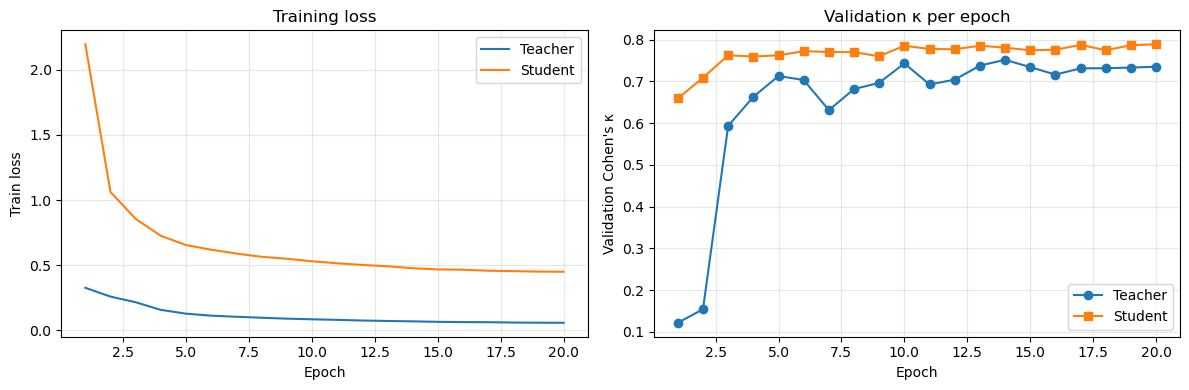

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(teacher_history["epoch"], teacher_history["train_loss"], label="Teacher")
axes[0].plot(student_history["epoch"], student_history["train_loss"], label="Student")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss")
axes[0].set_title("Training loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(teacher_history["epoch"], teacher_history["kappa"], label="Teacher", marker="o")
axes[1].plot(student_history["epoch"], student_history["kappa"], label="Student", marker="s")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Cohen's κ")
axes[1].set_title("Validation κ per epoch"); axes[1].legend(); axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Handoff to Notebook 05

`artifacts/final/student_full_finetuned.pt` is the single deployable checkpoint. Notebook 05 is the only notebook that publishes the official test metrics on it. Training logs are diagnostic artifacts and must not be turned into alternative final-result tables.